In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from pathlib import Path

In [83]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [41]:
root_path = Path().cwd().parent
songs_data_path = root_path / "data" / "raw" / "songs-info.csv"
user_data_path = root_path / "data"/ "raw" / "user-info.csv"

In [42]:
df_songs = pd.read_csv(songs_data_path)
df_songs.head()

,track_id,name,artist,pulse_play_preview_url,pulse_play_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


# EDA On Songs Dataset

# Preliminary Analysis

In [43]:
df_songs.shape

(50683, 21)

In [44]:
df_songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   track_id                50683 non-null  str    
 1   name                    50683 non-null  str    
 2   artist                  50683 non-null  str    
 3   pulse_play_preview_url  50683 non-null  str    
 4   pulse_play_id           50683 non-null  str    
 5   tags                    49556 non-null  str    
 6   genre                   22348 non-null  str    
 7   year                    50683 non-null  int64  
 8   duration_ms             50683 non-null  int64  
 9   danceability            50683 non-null  float64
 10  energy                  50683 non-null  float64
 11  key                     50683 non-null  int64  
 12  loudness                50683 non-null  float64
 13  mode                    50683 non-null  int64  
 14  speechiness             50683 non-null  float64
 

__Observations__

1. We have 3 types columns in the songs dataset -> (str,int,float).

In [45]:
# drop columns from data

columns_to_drop = ["pulse_play_preview_url"]

df_songs.drop(columns=columns_to_drop,inplace=True)

df_songs.head()

,track_id,name,artist,pulse_play_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


# Missing Values

In [46]:
# missing values

df_songs.isna().sum()

track_id                0
name                    0
artist                  0
pulse_play_id           0
tags                 1127
genre               28335
year                    0
duration_ms             0
danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
time_signature          0
dtype: int64

In [47]:
df_songs['tags'].value_counts(dropna=False,normalize=True)*100

tags
NaN                                            2.223625
country                                        0.998362
reggae                                         0.895764
black_metal                                    0.872087
rap, hip_hop                                   0.745812
                                                 ...   
alternative, japanese                          0.001973
rock, female_vocalists, hard_rock, japanese    0.001973
rock, instrumental, japanese                   0.001973
electronic, indie_pop, love                    0.001973
rock, alternative_rock, japanese, cover        0.001973
Name: proportion, Length: 20058, dtype: float64

In [48]:
(df_songs['tags'].isna().sum() / df_songs['tags'].shape[0])*100

np.float64(2.223625278693053)

In [49]:
df_songs['genre'].value_counts(dropna=False,normalize=True)*100

genre
NaN           55.906320
Rock          19.661425
Electronic     7.320009
Metal          4.964189
Pop            2.259140
Rap            1.619873
Jazz           1.564627
RnB            1.373242
Reggae         1.363376
Country        1.197640
Punk           0.755677
Folk           0.700432
New Age        0.467612
Blues          0.372906
World          0.276227
Latin          0.197305
Name: proportion, dtype: float64

<Axes: >

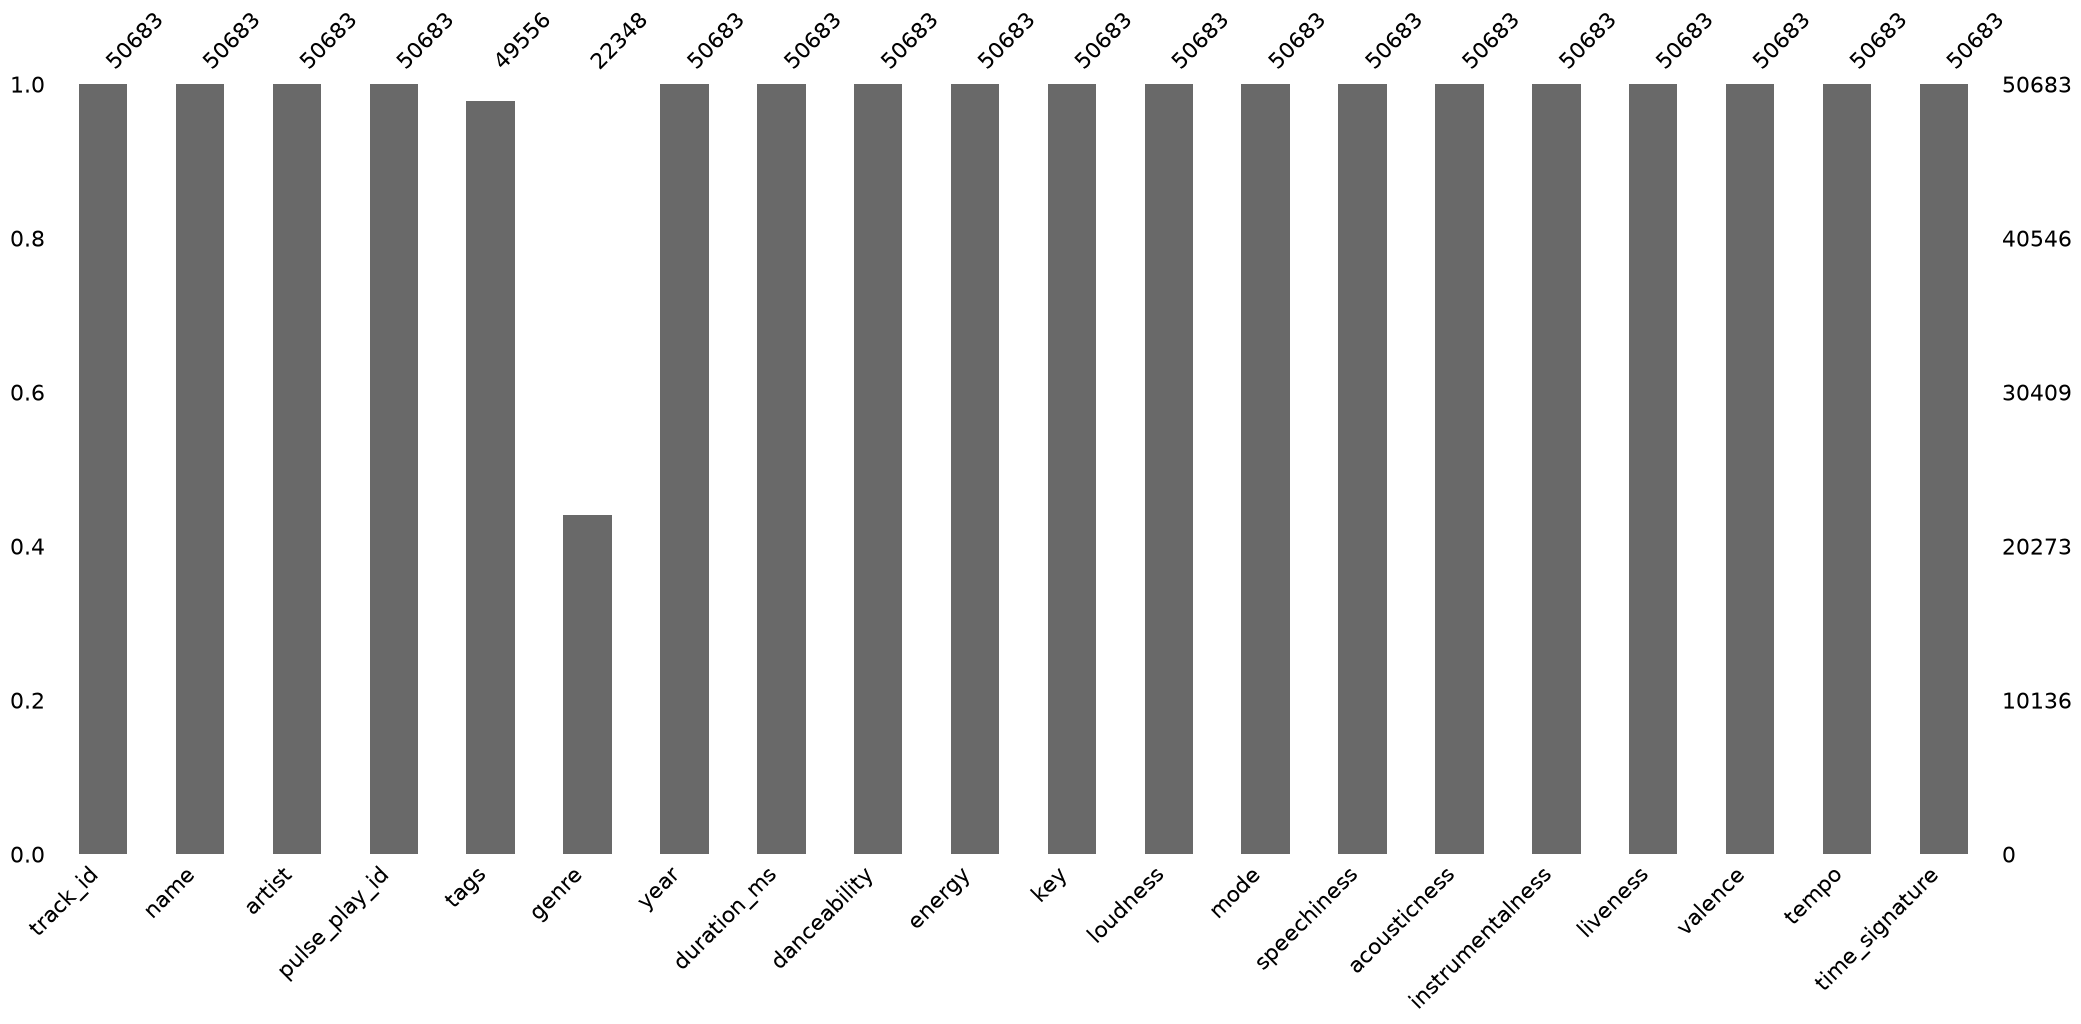

In [50]:
msno.bar(df_songs)

<Axes: >

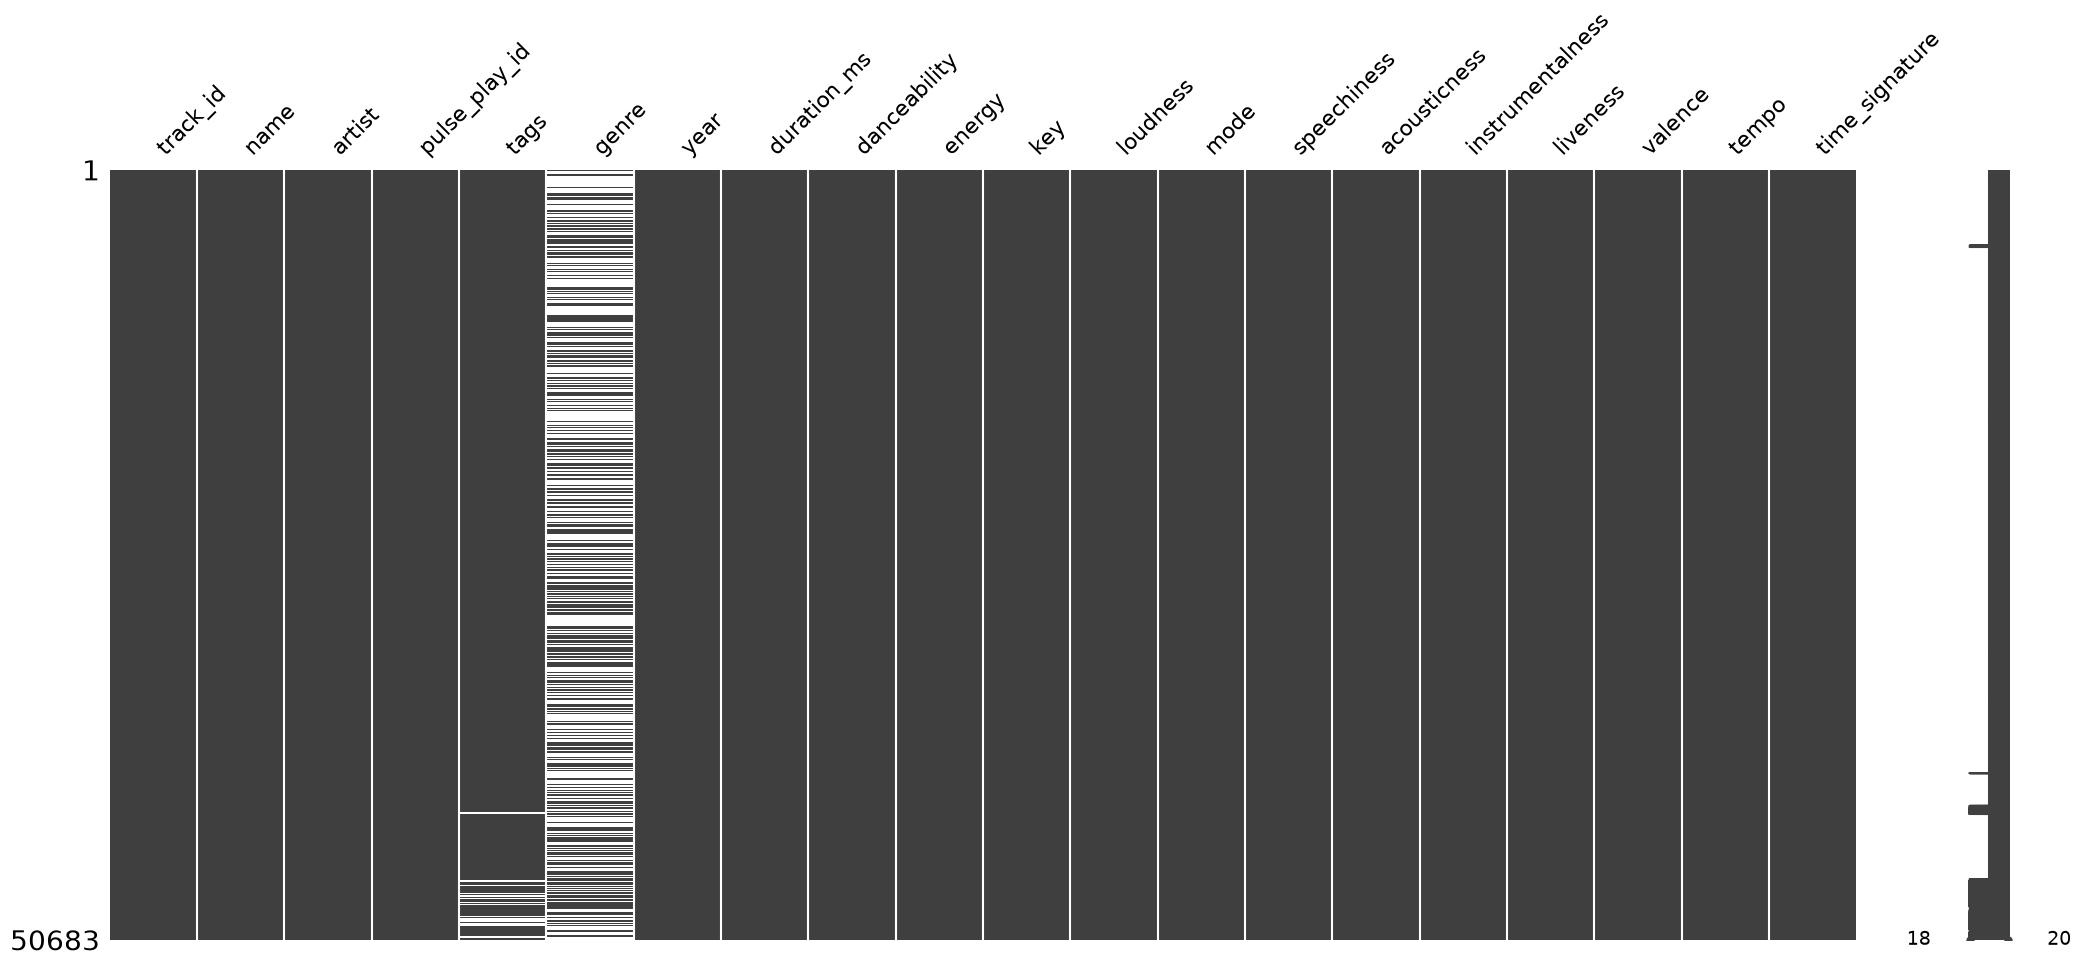

In [51]:
msno.matrix(df_songs)

__Observation__

1. I've 2.2% of missing values in Tags Column.
2. I've 56% of missing values in Genre Column. (If not successful in imputing values, then I can drop the column as well.)

# Duplicates in Dataset

In [52]:
df_songs.duplicated().sum()

np.int64(0)

In [55]:
df_songs.head()

,track_id,name,artist,pulse_play_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [57]:
df_songs['name'].str.lower().str.strip().duplicated().sum()

np.int64(815)

Song Names are duplicates. It can be a possibility.

In [63]:
df_songs[df_songs['name'].str.lower().str.strip().duplicated(keep=False)].sort_values('name')

,track_id,name,artist,pulse_play_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
6588,TRGGALK12903CB68E5,3 AM,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, pop, alternative_rock, 90s,...",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.00573,0.000000,0.120,0.5430,108.031,4
34480,TRKKZMK128F4257579,3 am,Liv Kristine,1TgsnkiolcBhQssCR37JXx,"female_vocalists, power_metal, gothic_metal, g...",NaN,2005,302880,0.516,0.840,0,-6.038,0,0.0390,0.15200,0.005970,0.107,0.4410,78.009,4
29795,TRLOXMF128F934BF04,3AM,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, 90s, piano, american, pop_rock",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.00573,0.000000,0.120,0.5430,108.031,4
43800,TRPWOAS128E0781045,3am,Halsey,1OfLNb6dQ9dra1B58iT9Ex,pop_rock,NaN,2020,234858,0.385,0.871,0,-4.604,0,0.0795,0.00906,0.000000,0.579,0.5380,189.760,4
38764,TRXEFAP128F9321AB7,4th Of July,Aimee Mann,2fW1zQeo6QEhZviaudZvBu,"rock, female_vocalists, singer_songwriter, gui...",NaN,2004,209173,0.432,0.296,5,-10.926,1,0.0325,0.85400,0.000022,0.983,0.2630,132.694,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40027,TRHLKXB128F9330FB4,the waves,All My Faith Lost ...,3yRACVTfhDtcgdlJBmAC2k,"gothic, dark_ambient",NaN,2007,271133,0.230,0.219,9,-13.877,0,0.0339,0.92900,0.897000,0.129,0.0671,75.432,3
39171,TRADNPA12903CBDADE,time to go,Wax Tailor,0IE64wOdOdeGXSOFjbHjRP,"indie, indie_rock, idm",NaN,2012,209920,0.671,0.786,7,-6.162,0,0.0855,0.19900,0.007400,0.360,0.3620,100.014,4
43632,TRAZKLR128F92C6584,under the sun,Do As Infinity,6AWpZWTZkuzCctkgh1mtbG,"japanese, j_pop",NaN,2009,241241,0.315,0.988,2,-1.206,0,0.0950,0.01310,0.810000,0.297,0.1840,129.809,4
50673,TROIHJK12903CECC08,you,High And Mighty Color,567nudtJeyQ5Tq9Ij9vmHe,"rock, female_vocalists, hard_rock, japanese",NaN,2009,241476,0.340,0.838,7,-4.434,1,0.0485,0.00191,0.055200,0.132,0.4030,174.018,4


In [65]:
df_songs['track_id'].duplicated().sum()

np.int64(0)

In [66]:
df_songs['pulse_play_id'].duplicated().sum()

np.int64(9)

In [69]:
df_songs.duplicated(subset=["pulse_play_id","year","duration_ms"]).sum()

np.int64(9)

__9 Duplicate songs in the data__

In [74]:
df_songs.loc[df_songs.duplicated(subset=["pulse_play_id","year","duration_ms"],keep=False)].sort_values(["pulse_play_id","year","duration_ms"])

,track_id,name,artist,pulse_play_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
15326,TRJNHPN128F92EF139,Adagio For Strings,Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,"instrumental, classical, soundtrack, beautiful",NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
21570,TRLSRQD128F426CFF8,"Adagio for Strings, Op. 11",Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,classical,NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
14861,TRLOZQZ128F92E8A3F,How Do You Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop",NaN,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
14981,TRXHJQY128F42B5094,How Do U Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop, american",Rap,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
37040,TRGCZFO128F92EE221,Je pense à toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,"alternative, beautiful, french",NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
49162,TRZBNQU128F148C04F,Je Pense A Toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,NaN,NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
13427,TRJQFIT128E0781CED,Too Much Too Young,The Specials,0ndKJL8gA4zLl317M7vndn,"punk, 80s, new_wave, reggae, ska",NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
46512,TRDTUTO128F422F138,Too Much Too Young (Live),The Specials,0ndKJL8gA4zLl317M7vndn,ska,NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
1684,TRRZUGN128F42A1EEE,There There,Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",Rock,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4
2983,TRXFHCL128F92E0989,"There, There",Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",NaN,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4


In [76]:
df_songs.drop_duplicates(subset=["pulse_play_id","year","duration_ms"],inplace=True)

In [77]:
df_songs.duplicated(subset=["pulse_play_id","year","duration_ms"]).sum()

np.int64(0)

__Duplicate songs have been removed from the data__

# Column Wise Analysis

# Categorical Columns

In [78]:
df_songs.columns

Index(['track_id', 'name', 'artist', 'pulse_play_id', 'tags', 'genre', 'year',
       'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='str')

In [79]:
df_songs.dtypes

track_id                str
name                    str
artist                  str
pulse_play_id           str
tags                    str
genre                   str
year                  int64
duration_ms           int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
dtype: object

In [80]:
categorical_features = df_songs.select_dtypes(include="object").columns
categorical_features

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_10016\2573356556.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df_songs.select_dtypes(include="object").columns


Index(['track_id', 'name', 'artist', 'pulse_play_id', 'tags', 'genre'], dtype='str')

In [92]:
def categorical_analysis(df,feature_names,k_artists=15):
    for feature in feature_names:
        print(f"Number of categories in column {feature} are ",df[feature].str.lower().nunique())

        if feature in ["artist","genre"]:
            print(df[feature].value_counts().head(k_artists))

        if feature == "genre":
            print(f"The unique categories in {feature} column are: ", df[feature].dropna().unique())
        print("#" * 75)

In [93]:
# perform catagorical analysis

categorical_analysis(df_songs,categorical_features)

Number of categories in column track_id are  50674
###########################################################################
Number of categories in column name are  49860
###########################################################################
Number of categories in column artist are  8317
artist
The Rolling Stones    132
Radiohead             110
Autechre              105
Tom Waits             100
Bob Dylan              98
The Cure               94
Metallica              85
Johnny Cash            84
Nine Inch Nails        83
Sonic Youth            81
Iron Maiden            76
Elliott Smith          76
In Flames              76
Boards of Canada       75
Mogwai                 75
Name: count, dtype: int64
###########################################################################
Number of categories in column pulse_play_id are  50674
###########################################################################
Number of categories in column tags are  20054
########################

__Observations:__

The Track ID and Spotify ID's are unique for every row.

The song names have some repititions. That is because there are a few songs in the data whose name is the same but is sung by a different artist.

The dataset contains songs of about 8317 artists.

There are 15 distinct categories in the Genre column.

Few Song Titles are not in english.

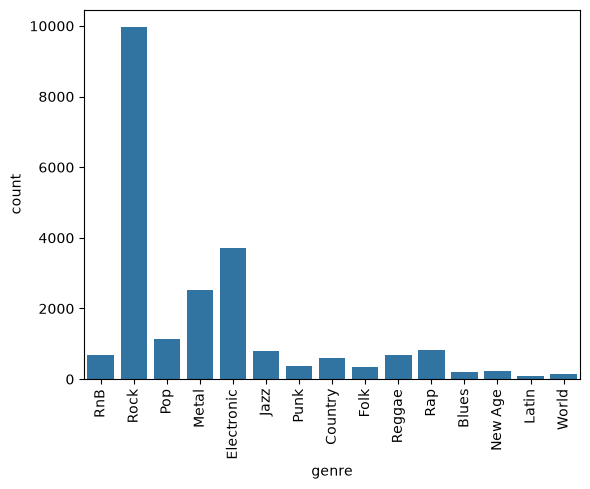

In [94]:
# countplot of genre

sns.countplot(df_songs,x="genre")
plt.xticks(rotation=90)
plt.show()

In [95]:
# genre group

genre_group = df_songs.groupby("genre")

genre_group[['genre','tags']].sample(3)

,genre,tags
20794,Blues,"pop, soul, rnb"
10335,Blues,"rock, classic_rock, folk, singer_songwriter, blues, 70s, blues_rock"
39533,Blues,"pop, britpop"
33056,Country,"country, love"
12770,Country,"folk, singer_songwriter, country, love"
33802,Country,country
46853,Electronic,electro
11934,Electronic,"indie, female_vocalists, experimental, chillout, indie_pop, beautiful, chill"
31365,Electronic,"electronic, chillout, trip_hop"
35899,Folk,doom_metal


__There is No clear evidence that I can find out a way to impute genre column.__

In [96]:
# song titles in the data that are not in english

(   df_songs
    .loc[
        df_songs
        .loc[:,"name"]
        .str.contains("[^\d\w\s.?!':;-_(){},\.#-&/-]")
    ]
)

,track_id,name,artist,pulse_play_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2455,TRBGIZH128F4252D9E,2 + 2 = 5,Radiohead,0dUSgj5UiJHY92RCuEFYcx,"rock, electronic, alternative, indie, alternative_rock, indie_rock, british, britpop",Rock,2008,199360,0.443,0.717,5,-5.498,0,0.0504,0.182000,0.000051,0.3450,0.3860,149.582,4
4463,TRGHMRU128F1478067,"I Put The ""Metro"" In Metronome",Cute Is What We Aim For,718VxOgHaLU7oGS9686hg6,"alternative, emo",Rock,2006,206053,0.538,0.858,11,-3.862,1,0.0638,0.085200,0.000000,0.2580,0.7060,149.971,4
6870,TRGIILN12903CE46BB,1+1,Beyoncé,0b4bcwV5QWTzgza5u1gh5C,"female_vocalists, soul, rnb, beautiful",NaN,2011,273880,0.303,0.384,6,-7.342,1,0.0339,0.381000,0.000005,0.0661,0.2610,63.345,5
7902,TRZMLSV128F9305C8C,B********,Rammstein,2fKyVXrtvFkqv5lVPf1UXa,"metal, industrial, german",Rock,2009,254013,0.352,0.905,9,-3.792,1,0.0836,0.000895,0.218000,0.1810,0.3270,141.016,3
7974,TRFRAEO128F4279C87,F**k the System,System of a Down,0uvPnGOwcaUNT6gwJF98wL,"metal, nu_metal",Metal,2002,132733,0.474,0.994,8,-1.884,1,0.1030,0.002160,0.126000,0.3140,0.8470,171.433,4
10722,TRODWHD128F92FD8BA,4 + 20,"Crosby, Stills, Nash & Young",2jZPEeW2ynykb2GkVqpOkJ,"rock, classic_rock, folk, singer_songwriter, acoustic, american, 70s, 60s",Rock,1970,126640,0.638,0.058,4,-25.243,1,0.0388,0.928000,0.079000,0.1130,0.1260,140.964,4
13127,TRLMIXB128EF3435DD,M+M's,blink-182,0z6VQdAqi0HjQYULMUYpBt,"punk, punk_rock",NaN,2005,155680,0.212,0.921,9,-6.092,1,0.0567,0.000054,0.003990,0.0669,0.6800,159.629,4
14454,TRKEIVB128F930A597,"Nuthin' But a ""G"" Thang",Dr. Dre,1qaZx6y94LiMy2KdhHxRTy,"rap, 90s, hip_hop",NaN,2005,230026,0.817,0.704,7,-8.336,1,0.2850,0.009390,0.000000,0.0850,0.6800,94.627,4
17862,TRBZLOG12903CB78FD,I Belong To You [+Mon Coeur S'Ouvre A Ta Voix],Muse,114rzL6VEy9bb3amPcY3tw,"rock, alternative_rock, progressive_rock, soundtrack, blues, male_vocalists, beautiful, french",Rock,2009,338813,0.481,0.603,2,-6.590,1,0.0280,0.166000,0.032100,0.1090,0.2130,105.974,4
22541,TRYVOPZ128F4254176,£4,These New Puritans,1LsQ5WkLU8ubiAz6AtMNll,"electronic, alternative, british, industrial, noise",Rock,2008,133173,0.692,0.759,11,-9.216,1,0.0533,0.052200,0.012900,0.4630,0.2560,99.988,4


In [97]:
# song titles in the data that are not in english

(   df_songs
    .loc[
        df_songs
        .loc[:,"artist"]
        .str.contains("[^\d\w\s.?!':;-_(){},\.#-&/-]")
    ]
)

,track_id,name,artist,pulse_play_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
419,TRMYECS128F92DE4B4,Rabbit Heart (Raise It Up),Florence + the Machine,0AXtUwPpFDkNLcOzNZH4ir,"rock, alternative, indie, pop, female_vocalists, british, indie_pop",Rock,2010,232360,0.625,0.8580,9,-3.483,0,0.0462,0.092000,0.000001,0.2660,0.4180,116.980,4
627,TRBSOCU128F147CD97,Howl,Florence + the Machine,0O8rwnPniPEUX71uLpSIE6,"rock, alternative, indie, female_vocalists, indie_rock, british, indie_pop, beautiful",Rock,2009,214053,0.584,0.8580,0,-4.026,1,0.0654,0.007800,0.000467,0.1660,0.2730,129.998,4
703,TRMAJOR128F92F990D,Drumming Song,Florence + the Machine,0idoUYxPn2oQFjk85p3KQk,"rock, alternative, indie, female_vocalists, indie_rock, british, indie_pop",Rock,2009,223826,0.444,0.8100,4,-4.790,0,0.0434,0.001270,0.000952,0.0958,0.4960,199.971,4
941,TRRWJLU128F92F9912,My Boy Builds Coffins,Florence + the Machine,1KxcbEY0asYVMR043MjZWq,"rock, alternative, indie, pop, female_vocalists, british, indie_pop",Rock,2009,176733,0.615,0.7210,5,-6.244,1,0.0740,0.172000,0.000000,0.0847,0.1880,122.042,4
1062,TRPVKQM128F932BE00,Hurricane Drunk,Florence + the Machine,0dj6mtoqOvAtBtfXsy2BG0,"rock, alternative, indie, pop, female_vocalists, british, indie_pop",NaN,2009,193346,0.427,0.8650,4,-4.691,1,0.2060,0.163000,0.000022,0.3160,0.2080,184.310,4
1146,TRUWOAH128F92F9914,Blinding,Florence + the Machine,0yqyGx47rQuY4OGTCv990p,"rock, alternative, indie, female_vocalists, alternative_rock, indie_rock, british, indie_pop",NaN,2009,280066,0.514,0.7860,0,-6.165,1,0.0396,0.120000,0.013100,0.7950,0.2550,108.003,4
2876,TRFFAHO128F9316F9D,Gonna Make You Sweat (Everybody Dance Now),C+C Music Factory,0325ztu7BtVLsKeJX22tu7,"electronic, pop, dance, 90s, house",NaN,2011,245800,0.561,0.8580,6,-6.992,1,0.0873,0.001730,0.330000,0.1260,0.8060,113.876,4
2974,TRVLGKP128E078FA09,Remain Nameless,Florence + the Machine,00MGAk32pgqhyOW3rPhWNv,"electronic, indie, female_vocalists, british, indie_pop, beautiful",NaN,2011,241248,0.535,0.4970,0,-9.216,1,0.0300,0.001400,0.026700,0.0816,0.1490,176.038,4
3825,TRLABWR128F92E937B,Lycanthrope,+44,1g5CHtsDQl7KVWaUiAwat0,"rock, alternative, punk, punk_rock, emo",Rock,2006,237533,0.362,0.9890,9,-2.377,0,0.1080,0.000039,0.000000,0.0616,0.3800,168.061,4
4051,TRIOONU128F4281B6B,Lillian,+44,0mTYsPh5IaQV7XPdU4gBfI,"rock, alternative, punk, punk_rock",Rock,2006,278506,0.601,0.6560,0,-7.911,1,0.0368,0.016700,0.000004,0.3620,0.0512,105.237,3


In [98]:
df_songs['tags'][0]

'rock, alternative, indie, alternative_rock, indie_rock, 00s'

In [99]:
all_tags = []

for tags in df_songs["tags"].dropna().str.replace(" ","").str.split(","):
    all_tags.extend(tags)

In [101]:
print("The number of unique tags are ",len(set(all_tags)))

The number of unique tags are  100


In [103]:
set(all_tags)

{'00s',
 '60s',
 '70s',
 '80s',
 '90s',
 'acoustic',
 'alternative',
 'alternative_rock',
 'ambient',
 'american',
 'avant_garde',
 'beautiful',
 'black_metal',
 'blues',
 'blues_rock',
 'british',
 'britpop',
 'chill',
 'chillout',
 'classic_rock',
 'classical',
 'country',
 'cover',
 'dance',
 'dark_ambient',
 'death_metal',
 'doom_metal',
 'downtempo',
 'drum_and_bass',
 'electro',
 'electronic',
 'emo',
 'experimental',
 'female_vocalists',
 'folk',
 'french',
 'funk',
 'german',
 'gothic',
 'gothic_metal',
 'grindcore',
 'grunge',
 'guitar',
 'hard_rock',
 'hardcore',
 'heavy_metal',
 'hip_hop',
 'house',
 'idm',
 'indie',
 'indie_pop',
 'indie_rock',
 'industrial',
 'instrumental',
 'j_pop',
 'japanese',
 'jazz',
 'lounge',
 'love',
 'male_vocalists',
 'mellow',
 'melodic_death_metal',
 'metal',
 'metalcore',
 'new_age',
 'new_wave',
 'noise',
 'nu_metal',
 'oldies',
 'piano',
 'polish',
 'pop',
 'pop_rock',
 'post_hardcore',
 'post_punk',
 'post_rock',
 'power_metal',
 'progress

In [108]:
df_songs.loc[:,"tags"].dropna().str.split(",").explode().str.strip().unique()

<StringArray>
[               'rock',         'alternative',               'indie',
    'alternative_rock',          'indie_rock',                 '00s',
                 'pop',             'british',                 '90s',
                'love',             'britpop',              'grunge',
               'piano',           'beautiful',              'mellow',
            'chillout',                'funk',          'electronic',
               'dance',             'hip_hop',            'trip_hop',
               'metal',           'hard_rock',            'nu_metal',
    'progressive_rock',        'classic_rock',                 '80s',
                 '70s',        'experimental',          'soundtrack',
    'female_vocalists',         'heavy_metal',                 'rap',
                 '60s',           'post_punk',            'pop_rock',
                'punk',           'punk_rock',            'acoustic',
                 'emo',            'new_wave',               'chill',
      

# Integer Based Columns

**Key**  

**What it means:** The musical key in which the song is composed, represented as integers (e.g., 0 = C, 1 = C#, 2 = D, etc., up to 11).  
- **When value is small:** Represents keys like C or D, often associated with simplicity or familiarity.  
- **When value is large:** Represents keys like A# or B, which may sound brighter or more complex, depending on the context.  

---

**Mode**  

**What it means:** Refers to the modality of the song, where 0 = minor (often associated with sadness or tension) and 1 = major (associated with happiness or resolution).  
- **When value is small:** Indicates the song is in a minor mode, creating a more somber or serious tone.  
- **When value is large:** Indicates the song is in a major mode, giving it a cheerful and uplifting feel.  

---

**Time Signature**  

**What it means:** The number of beats in each bar of music, typically expressed as an integer (e.g., 4 for 4/4 time).  
- **When value is small:** Indicates fewer beats per measure (e.g., 3), which can create a waltz-like or less conventional rhythm.  
- **When value is large:** Indicates more beats per measure (e.g., 5 or 7), often leading to a more complex or experimental rhythmic structure.


> A value of **4** in the time signature typically means the song is in **4/4 time**, also known as "common time." This means there are **4 beats per measure**, and the quarter note gets one beat.

>**Impact of a 4 Time Signature:**  
- **Musical Feel:** It creates a steady, balanced, and natural rhythm that is easy to follow.  
- **Prevalence:** It is the most common time signature in Western music, used in many genres like pop, rock, classical, and jazz.  
- **Examples:** Songs like "Billie Jean" by Michael Jackson or "Shape of You" by Ed Sheeran are in 4/4.


In [109]:
integer_columns = df_songs.select_dtypes(include="int").columns
integer_columns

Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='str')

In [110]:
df_songs.loc[:,integer_columns].drop(columns=["duration_ms"]).assign(**{
        col: df_songs[col].astype("object")
        for col in integer_columns.drop("duration_ms")
    }).describe()

,year,key,mode,time_signature
count,50674,50674,50674,50674
unique,75,12,2,5
top,2007,9,1,4
freq,4221,5907,31979,44981


In [111]:
(
    df_songs
    .loc[:,integer_columns]
    .assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60))
    .drop(columns=["duration_ms"])
    .agg(["min","max"])
)

,year,key,mode,time_signature,duration_minutes
min,1900,0,0,0,0.023983
max,2022,11,1,5,63.606217


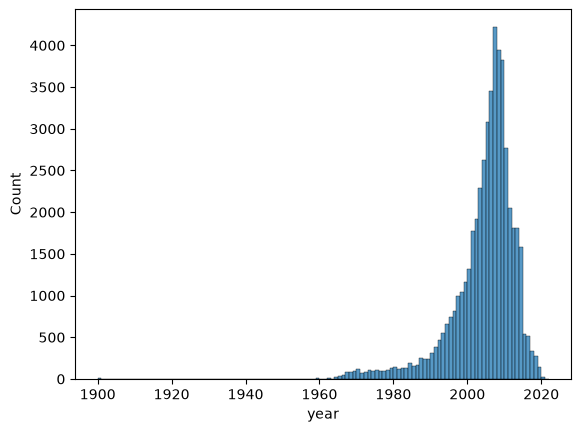

In [112]:
# number of songs per year in data

sns.histplot(df_songs,x="year",bins=df_songs["year"].max() - df_songs["year"].min(),stat="count")
plt.show()

__Understanding Keys Using AI.__

Musical notes are assigned key values from **0 to 11**, representing all the chromatic notes in an octave. Here’s the mapping:  

| **Key Value** | **Note** |  
|---------------|-----------|  
| 0             | C         |  
| 1             | C# / Db   |  
| 2             | D         |  
| 3             | D# / Eb   |  
| 4             | E         |  
| 5             | F         |  
| 6             | F# / Gb   |  
| 7             | G         |  
| 8             | G# / Ab   |  
| 9             | A         |  
| 10            | A# / Bb   |  
| 11            | B         |  

### Notes Explained:  
- **Sharps (#):** Raise the note by a semitone (e.g., C → C#).  
- **Flats (b):** Lower the note by a semitone (e.g., D → Db).  

This cycle repeats across octaves!

**English vs Hindi Notes Comparison**

Here’s a table that maps **Key Value**, **English Notes**, and their corresponding **Hindi Music Notes (Swaras)**:  

| **Key Value** | **English Note** | **Hindi Music Note** |  
|---------------|------------------|-----------------------|  
| 0             | C                | Sa                   |  
| 1             | C# / Db          | Komal Re             |  
| 2             | D                | Re                   |  
| 3             | D# / Eb          | Komal Ga             |  
| 4             | E                | Ga                   |  
| 5             | F                | Ma                   |  
| 6             | F# / Gb          | Tivra Ma             |  
| 7             | G                | Pa                   |  
| 8             | G# / Ab          | Komal Dha            |  
| 9             | A                | Dha                  |  
| 10            | A# / Bb          | Komal Ni             |  
| 11            | B                | Ni                   |  

**Notes**:
- In **Hindi classical music**, "Komal" refers to flat (lowered) notes, and "Tivra" refers to sharp (raised) notes.
- The cycle repeats with "Sa" at the next octave!

-----

If a song has a key value of **2**, it means the song is composed in the **D major** or **D minor key**, depending on the **mode** (0 = minor, 1 = major).  

**Interpretation**:              
- **Key Value 2 (D):** The tonic note, or "home base," of the song is **D**. All other notes and chords in the song revolve around this note.
- **In Western Music:**  
  - **D Major:** Bright and uplifting.  
  - **D Minor:** Melancholic or introspective.
- **In Hindi Classical Music:** This corresponds to the "Re" swara (if D is treated as the Sa of the scale).

The overall mood or emotion of the song will depend on the mode and how the scale is used melodically and harmonically.

In [116]:
np.sort(df_songs['key'].unique())

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

<Axes: title={'center': 'Percentage of Songs wrt to Key'}, xlabel='Percentage', ylabel='key'>

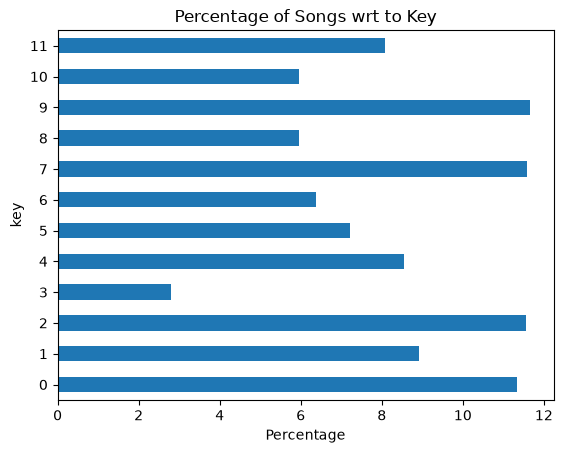

In [117]:
df_songs['key'].value_counts(normalize=True).mul(100).sort_index().plot(kind='barh',title="Percentage of Songs wrt to Key",xlabel="Percentage")

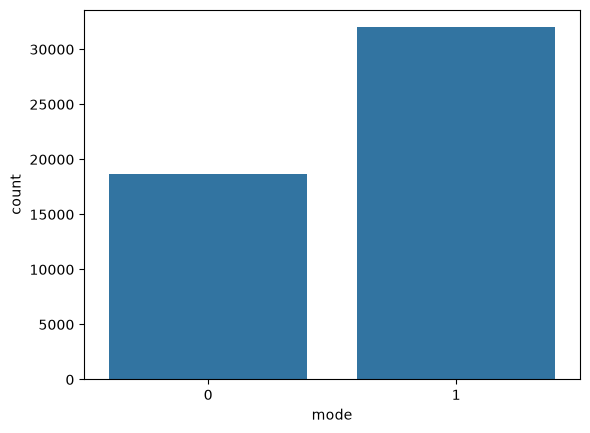

In [118]:
# countplot for mode

sns.countplot(df_songs,x="mode")
plt.show()

In [119]:
np.sort(df_songs.loc[:,"time_signature"].unique())

array([0, 1, 3, 4, 5])

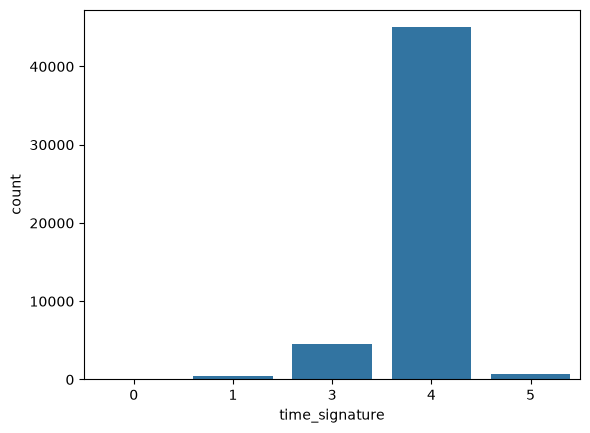

In [120]:
# countplot for time signature

sns.countplot(df_songs,x="time_signature")
plt.show()

In [121]:
df_songs['time_signature'].value_counts(normalize=True).mul(100)

time_signature
4    88.765442
3     8.880294
5     1.444528
1     0.890003
0     0.019734
Name: proportion, dtype: float64

In [122]:
df_songs.loc[:,["duration_ms"]].assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60)).drop(columns="duration_ms").describe()

,duration_minutes
count,50674.000000
mean,4.185893
std,1.793154
min,0.023983
25%,3.212217
50%,3.915550
75%,4.803046
max,63.606217


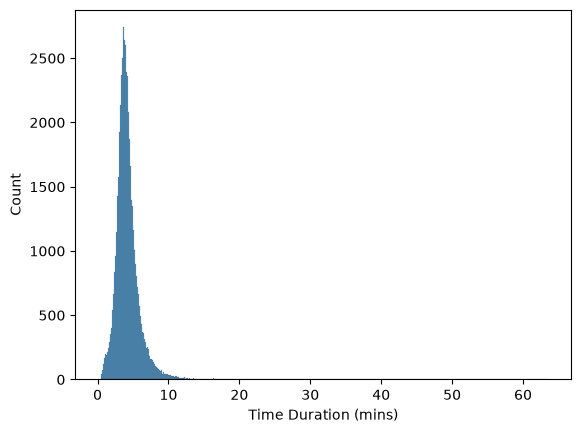

In [123]:
# time duration histogram

time_duration_mins = df_songs["duration_ms"].div(1000).div(60)

sns.histplot(time_duration_mins)
plt.xlabel("Time Duration (mins)")
plt.show()

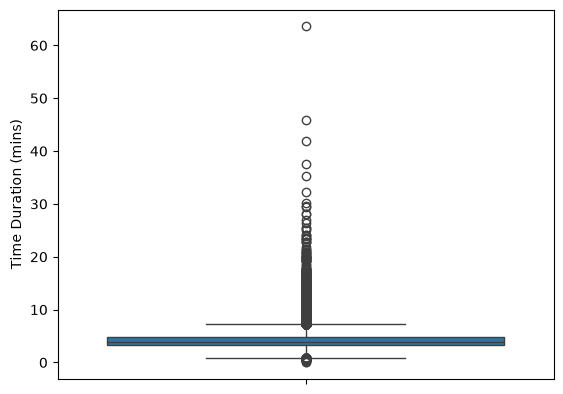

In [124]:
# time duration boxplot

sns.boxplot(time_duration_mins)
plt.ylabel("Time Duration (mins)")
plt.show()

In [125]:
df_songs.loc[time_duration_mins > 60]

,track_id,name,artist,pulse_play_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
25337,TRDAOJL128F932C383,Dopesmoker,Sleep,1vhvheW4R0KbK6Kr3NFplW,"psychedelic, doom_metal",NaN,2003,3816373,0.16,0.572,5,-6.949,1,0.0321,0.00367,0.745,0.0952,0.0932,96.926,4


__Observations__

1. Even Though it is an outlier but we cannot remove it while building recommender system.